# Unidad 3: Búsqueda, Optimización y Agentes Inteligentes
## 🧩 Resolución de Laberinto — BFS y DFS
### Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CristianPacifico/ia-ls-fcad-uner/blob/main/notebooks/search/01a_Laberinto_BFS_DFS.ipynb)

---

## 🎯 Objetivos de Aprendizaje

Al finalizar este notebook vas a poder:

✅ Formular el **problema del laberinto** como un problema de búsqueda en un espacio de estados  
✅ Implementar **BFS** (Búsqueda en Anchura) y **DFS** (Búsqueda en Profundidad) desde cero  
✅ Comprender la diferencia entre la **cola (FIFO)** de BFS y la **pila (LIFO)** de DFS  
✅ Comparar los caminos encontrados por cada algoritmo y analizar sus propiedades  
✅ Visualizar el laberinto y la solución con `matplotlib`

---

## 📖 Marco Teórico

### El problema del laberinto como búsqueda

Un laberinto puede representarse como un **grafo de estados** donde:
- **Estado**: posición `(fila, columna)` en la grilla
- **Estado inicial**: celda de partida
- **Estado meta**: celda de destino
- **Acciones**: moverse en las 4 direcciones (arriba, abajo, izquierda, derecha)
- **Restricciones**: no atravesar paredes (`1`) ni salir del laberinto

```
  0  1  2  3  4  5
0[·][·][·][·][·][■]
1[·][■][·][■][·][■]
2[·][■][·][·][·][·]
3[·][·][·][■][■][·]
4[·][■][·][·][·][·]
5[■][·][·][■][■][·]
  inicio(0,0)     fin(5,5)
```

### BFS vs DFS

| Propiedad | BFS | DFS |
|-----------|-----|-----|
| Estructura de datos | Cola (FIFO) | Pila (LIFO) |
| Orden de exploración | Nivel por nivel | Rama hasta el fondo |
| **Completo** (siempre encuentra solución si existe) | ✅ Sí | ⚠️ Sí (en grafos finitos) |
| **Óptimo** (encuentra el camino más corto) | ✅ Sí (costo igual) | ❌ No |
| Uso de memoria | Alto ⚠️ | Bajo ✅ |
| Velocidad (en grafos densos) | Más lento | Más rápido |

> **Clave**: BFS garantiza el **camino más corto** (en número de pasos). DFS puede encontrar un camino más largo pero usa menos memoria.

## 📦 Paso 1: Importaciones

**NumPy** permite representar el laberinto como una matriz, facilitando el acceso y la manipulación de sus celdas.  
**Matplotlib** se usa para visualizar el laberinto y el camino encontrado.  
**queue.Queue** provee la estructura FIFO necesaria para BFS.

In [1]:
import numpy as np
import queue
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("✅ Librerías importadas")

✅ Librerías importadas


## 🗺️ Paso 2: Definición del laberinto

Se define un laberinto de 6×6 usando un arreglo de NumPy:
- **`0`** → celda transitable (camino libre)
- **`1`** → pared (infranqueable)

```
  col→  0  1  2  3  4  5
fila 0 [·][·][·][·][·][■]
fila 1 [·][■][·][■][·][■]
fila 2 [·][■][·][·][·][·]
fila 3 [·][·][·][■][■][·]
fila 4 [·][■][·][·][·][·]
fila 5 [■][·][·][■][■][·]
```

Inicio: `(0, 0)` — arriba a la izquierda  
Destino: `(5, 5)` — abajo a la derecha

In [2]:
# Laberinto 6x6 (0 = camino libre, 1 = pared)
laberinto = np.array([
    [0, 0, 0, 0, 0, 1],
    [0, 1, 0, 1, 0, 1],
    [0, 1, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 0],
    [0, 1, 0, 0, 0, 0],
    [1, 0, 0, 1, 1, 0]
])

print(f"Dimensiones del laberinto: {laberinto.shape}")
print(f"Celdas libres: {(laberinto == 0).sum()}")
print(f"Paredes: {(laberinto == 1).sum()}")
print("\nMatriz del laberinto:")
print(laberinto)

Dimensiones del laberinto: (6, 6)
Celdas libres: 25
Paredes: 11

Matriz del laberinto:
[[0 0 0 0 0 1]
 [0 1 0 1 0 1]
 [0 1 0 0 0 0]
 [0 0 0 1 1 0]
 [0 1 0 0 0 0]
 [1 0 0 1 1 0]]


## 📍 Paso 3: Punto de inicio, destino y movimientos

Se definen:
- `inicio`: coordenadas de partida `(fila, columna)`
- `fin`: coordenadas de llegada
- `movimientos`: desplazamientos posibles en las 4 direcciones cardinales

```
         (-1, 0) ↑ arriba
  (0,-1) ← ─── [X] ─── → (0, 1)
         (1, 0) ↓ abajo
```

In [3]:
inicio = (0, 0)   # Esquina superior izquierda
fin    = (5, 5)   # Esquina inferior derecha

# (delta_fila, delta_columna)
movimientos = [
    ( 1,  0),   # abajo
    ( 0,  1),   # derecha
    (-1,  0),   # arriba
    ( 0, -1),   # izquierda
]

print(f"Inicio : {inicio}")
print(f"Fin    : {fin}")
print(f"Movimientos posibles: {movimientos}")

Inicio : (0, 0)
Fin    : (5, 5)
Movimientos posibles: [(1, 0), (0, 1), (-1, 0), (0, -1)]


## 🖼️ Paso 4: Función de visualización y laberinto inicial

La función `mostrar_laberinto()` dibuja:
- El laberinto en escala de grises (blanco = libre, negro = pared)
- El camino encontrado en rojo
- El inicio en verde y el destino en azul

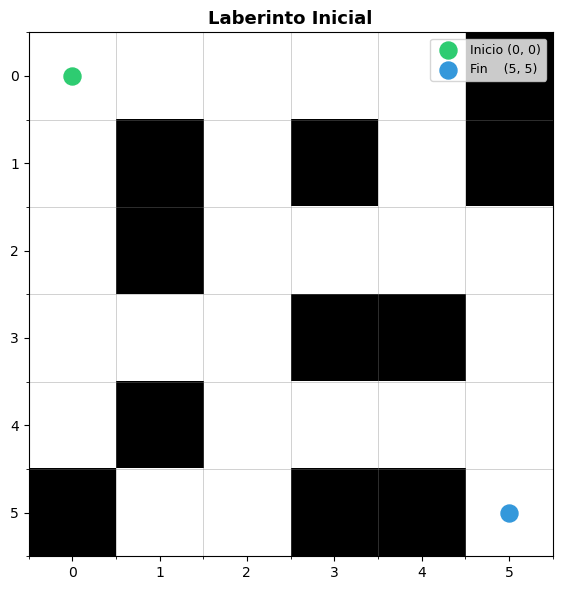

In [4]:
def mostrar_laberinto(laberinto, camino=None, titulo="Laberinto"):
    """
    Visualiza el laberinto y opcionalmente el camino encontrado.
    Args:
        laberinto: array NumPy (0=libre, 1=pared)
        camino   : lista de tuplas (fila, col) o None
        titulo   : título del gráfico
    """
    fig, ax = plt.subplots(figsize=(6, 6))

    # Mostrar el laberinto (escala de grises invertida)
    ax.imshow(laberinto, cmap="gray_r", vmin=0, vmax=1)

    # Dibujar el camino
    if camino:
        camino_x, camino_y = zip(*camino)
        ax.plot(camino_y, camino_x,
                marker="o", color="#e74c3c",
                markersize=8, linewidth=2.5, label="Camino")

    # Marcar inicio y fin
    ax.scatter(inicio[1], inicio[0], color="#2ecc71", s=150, zorder=5,
               label=f"Inicio {inicio}")
    ax.scatter(fin[1],   fin[0],   color="#3498db", s=150, zorder=5,
               label=f"Fin    {fin}")

    # Cuadrícula
    filas, cols = laberinto.shape
    ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, filas, 1), minor=True)
    ax.grid(which="minor", color="gray", linewidth=0.5, alpha=0.5)
    ax.set_xticks(range(cols))
    ax.set_yticks(range(filas))

    if camino:
        ax.set_title(f"{titulo}  (pasos: {len(camino)})",
                     fontsize=13, fontweight="bold")
    else:
        ax.set_title(titulo, fontsize=13, fontweight="bold")

    ax.legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.show()


# Mostrar el laberinto vacío
mostrar_laberinto(laberinto, titulo="Laberinto Inicial")

## 🔵 Paso 5: Algoritmo BFS — Búsqueda en Anchura

BFS utiliza una **cola FIFO** (`queue.Queue`): el primer camino que entra es el primero en explorarse.  
Esto garantiza que se expanden **todos los nodos de nivel $d$** antes de explorar los de nivel $d+1$, lo que asegura **optimalidad** (camino más corto).

```
Nivel 0:  (0,0)
Nivel 1:  (1,0), (0,1)
Nivel 2:  (2,0), (0,2)
...
```

**Algoritmo:**
1. Encolar el camino `[inicio]`
2. Mientras la cola no esté vacía:
   - Desencolar el primer camino
   - Si el último nodo es la meta → devolver el camino
   - Si ya fue visitado → continuar
   - Marcar como visitado y encolar los vecinos válidos

In [5]:
def bfs(laberinto, inicio, fin, verbose=True):
    """
    Búsqueda en Anchura (BFS) sobre un laberinto.
    Usa una cola FIFO. Garantiza el camino más corto.

    Returns:
        Lista de tuplas (fila, col) con el camino, o None si no existe solución.
    """
    filas, columnas = laberinto.shape
    visitado = set()
    cola = queue.Queue()
    cola.put([inicio])

    if verbose:
        print("Iniciando BFS...\n")

    while not cola.empty():
        camino = cola.get()          # FIFO: primer elemento encolado
        x, y = camino[-1]            # Nodo actual

        if verbose:
            print(f"Expandiendo nodo: ({x},{y})")

        if (x, y) == fin:
            if verbose:
                print("\n¡Camino encontrado!")
            return camino

        if (x, y) in visitado:
            continue

        visitado.add((x, y))
        vecinos = []

        for dx, dy in movimientos:
            nx, ny = x + dx, y + dy
            if (0 <= nx < filas and 0 <= ny < columnas
                    and laberinto[nx, ny] == 0):
                vecinos.append(f"({nx},{ny})")
                if (nx, ny) not in visitado:
                    cola.put(list(camino) + [(nx, ny)])

        if verbose and vecinos:
            print(f"  → Vecinos válidos: {', '.join(vecinos)}")

        if verbose:
            contenido = list(cola.queue)
            print("  → Caminos en cola:")
            for c in contenido:
                print("      " + " → ".join([f"({r},{c_})" for r, c_ in c]))
            print("-" * 50)

    print("\nNo se encontró solución.")
    return None

## ▶️ Paso 6: Ejecutar BFS y visualizar el resultado

In [6]:
camino_bfs = bfs(laberinto, inicio, fin, verbose=True)

Iniciando BFS...

Expandiendo nodo: (0,0)
  → Vecinos válidos: (1,0), (0,1)
  → Caminos en cola:
      (0,0) → (1,0)
      (0,0) → (0,1)
--------------------------------------------------
Expandiendo nodo: (1,0)
  → Vecinos válidos: (2,0), (0,0)
  → Caminos en cola:
      (0,0) → (0,1)
      (0,0) → (1,0) → (2,0)
--------------------------------------------------
Expandiendo nodo: (0,1)
  → Vecinos válidos: (0,2), (0,0)
  → Caminos en cola:
      (0,0) → (1,0) → (2,0)
      (0,0) → (0,1) → (0,2)
--------------------------------------------------
Expandiendo nodo: (2,0)
  → Vecinos válidos: (3,0), (1,0)
  → Caminos en cola:
      (0,0) → (0,1) → (0,2)
      (0,0) → (1,0) → (2,0) → (3,0)
--------------------------------------------------
Expandiendo nodo: (0,2)
  → Vecinos válidos: (1,2), (0,3), (0,1)
  → Caminos en cola:
      (0,0) → (1,0) → (2,0) → (3,0)
      (0,0) → (0,1) → (0,2) → (1,2)
      (0,0) → (0,1) → (0,2) → (0,3)
--------------------------------------------------
Expandien


Camino BFS (11 pasos):
(0,0) → (1,0) → (2,0) → (3,0) → (3,1) → (3,2) → (4,2) → (4,3) → (4,4) → (4,5) → (5,5)


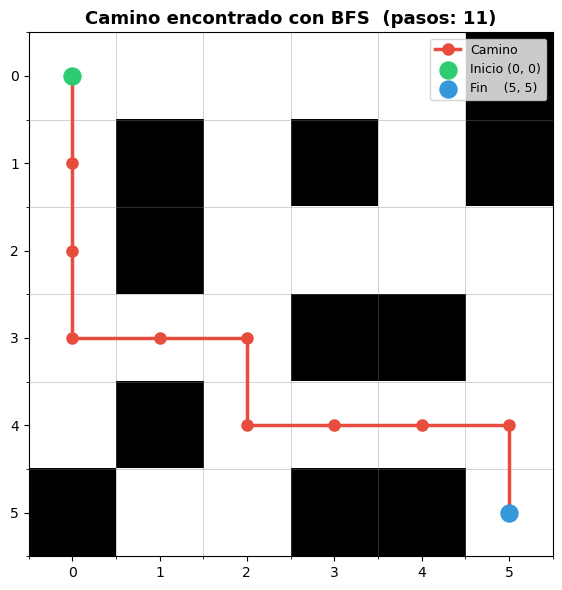

In [7]:
if camino_bfs:
    print(f"\nCamino BFS ({len(camino_bfs)} pasos):")
    print(" → ".join([f"({r},{c})" for r, c in camino_bfs]))
mostrar_laberinto(laberinto, camino_bfs, "Camino encontrado con BFS")

## 🔴 Paso 7: Algoritmo DFS — Búsqueda en Profundidad

DFS utiliza una **pila LIFO**: el último camino que entra es el primero en explorarse.  
Esto provoca que el algoritmo **descienda lo más profundo posible** por una rama antes de retroceder (*backtracking*). No garantiza optimalidad.

```
Pila inicial: [(0,0)]
  → Extrae (0,0), apila vecinos: [(1,0)], [(0,1)]
  → Extrae (0,1) (tope), apila sus vecinos...
  → Continúa descendiendo por esa rama
```

**Algoritmo:**
1. Apilar el camino `[inicio]`
2. Mientras la pila no esté vacía:
   - Desapilar el último camino
   - Si el último nodo es la meta → devolver el camino
   - Si ya fue visitado → continuar
   - Marcar como visitado y apilar los vecinos válidos

In [8]:
def dfs(laberinto, inicio, fin, verbose=True):
    """
    Búsqueda en Profundidad (DFS) sobre un laberinto.
    Usa una pila LIFO. No garantiza el camino más corto.

    Returns:
        Lista de tuplas (fila, col) con el camino, o None si no existe solución.
    """
    filas, columnas = laberinto.shape
    visitado = set()
    pila = [[inicio]]                   # Pila de caminos

    if verbose:
        print("Iniciando DFS...\n")

    while pila:
        camino = pila.pop()             # LIFO: último elemento apilado
        x, y = camino[-1]              # Nodo actual

        if verbose:
            print(f"Expandiendo nodo: ({x},{y})")

        if (x, y) == fin:
            if verbose:
                print("\n¡Camino encontrado!")
            return camino

        if (x, y) in visitado:
            continue

        visitado.add((x, y))
        vecinos = []

        for dx, dy in movimientos:
            nx, ny = x + dx, y + dy
            if (0 <= nx < filas and 0 <= ny < columnas
                    and laberinto[nx, ny] == 0):
                if (nx, ny) not in visitado:
                    pila.append(list(camino) + [(nx, ny)])
                    vecinos.append(f"({nx},{ny})")

        if verbose and vecinos:
            print(f"  → Vecinos válidos: {', '.join(vecinos)}")

        if verbose:
            print("  → Caminos en pila (tope → base):")
            for c in reversed(pila):
                print("      " + " → ".join([f"({r},{c_})" for r, c_ in c]))
            print("-" * 50)

    print("\nNo se encontró solución.")
    return None

## ▶️ Paso 8: Ejecutar DFS y visualizar el resultado

In [10]:
camino_dfs = dfs(laberinto, inicio, fin, verbose=True)

Iniciando DFS...

Expandiendo nodo: (0,0)
  → Vecinos válidos: (1,0), (0,1)
  → Caminos en pila (tope → base):
      (0,0) → (0,1)
      (0,0) → (1,0)
--------------------------------------------------
Expandiendo nodo: (0,1)
  → Vecinos válidos: (0,2)
  → Caminos en pila (tope → base):
      (0,0) → (0,1) → (0,2)
      (0,0) → (1,0)
--------------------------------------------------
Expandiendo nodo: (0,2)
  → Vecinos válidos: (1,2), (0,3)
  → Caminos en pila (tope → base):
      (0,0) → (0,1) → (0,2) → (0,3)
      (0,0) → (0,1) → (0,2) → (1,2)
      (0,0) → (1,0)
--------------------------------------------------
Expandiendo nodo: (0,3)
  → Vecinos válidos: (0,4)
  → Caminos en pila (tope → base):
      (0,0) → (0,1) → (0,2) → (0,3) → (0,4)
      (0,0) → (0,1) → (0,2) → (1,2)
      (0,0) → (1,0)
--------------------------------------------------
Expandiendo nodo: (0,4)
  → Vecinos válidos: (1,4)
  → Caminos en pila (tope → base):
      (0,0) → (0,1) → (0,2) → (0,3) → (0,4) → (1,4)
  


Camino DFS (15 pasos):
(0,0) → (0,1) → (0,2) → (0,3) → (0,4) → (1,4) → (2,4) → (2,3) → (2,2) → (3,2) → (4,2) → (4,3) → (4,4) → (4,5) → (5,5)


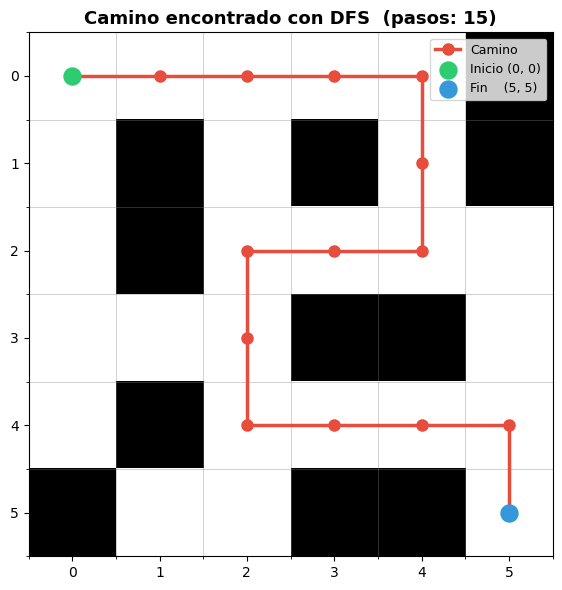

In [11]:
if camino_dfs:
    print(f"\nCamino DFS ({len(camino_dfs)} pasos):")
    print(" → ".join([f"({r},{c})" for r, c in camino_dfs]))
mostrar_laberinto(laberinto, camino_dfs, "Camino encontrado con DFS")

## 📊 Paso 9: Comparativa BFS vs DFS

Comparamos ambos algoritmos sobre el mismo laberinto.

=== Comparativa BFS vs DFS ===
Algoritmo  Pasos del camino    Camino óptimo Estructura de datos Tiempo (ms)
      BFS                11             ✅ Sí         Cola (FIFO)       0.157
      DFS                15 ❌ No garantizado         Pila (LIFO)       0.064


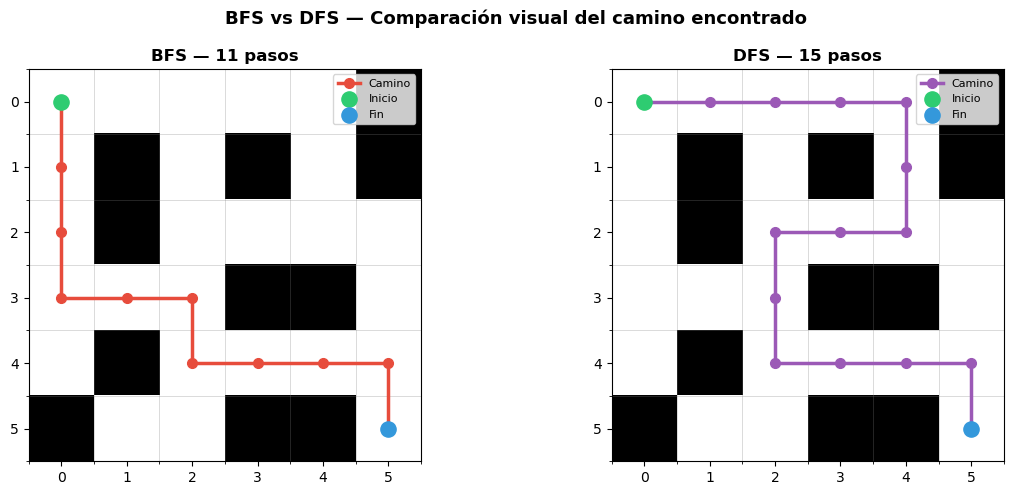

In [12]:
import time
import pandas as pd

# Medir tiempos
t0 = time.perf_counter()
bfs(laberinto, inicio, fin, verbose=False)
t_bfs = time.perf_counter() - t0

t0 = time.perf_counter()
dfs(laberinto, inicio, fin, verbose=False)
t_dfs = time.perf_counter() - t0

# Tabla comparativa
df = pd.DataFrame({
    'Algoritmo'           : ['BFS', 'DFS'],
    'Pasos del camino'    : [len(camino_bfs) if camino_bfs else 'N/A',
                             len(camino_dfs) if camino_dfs else 'N/A'],
    'Camino óptimo'       : ['✅ Sí', '❌ No garantizado'],
    'Estructura de datos' : ['Cola (FIFO)', 'Pila (LIFO)'],
    'Tiempo (ms)'         : [f'{t_bfs*1000:.3f}', f'{t_dfs*1000:.3f}'],
})

print("=== Comparativa BFS vs DFS ===")
print(df.to_string(index=False))

# Visualización lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, camino, titulo, color in [
    (axes[0], camino_bfs, f"BFS — {len(camino_bfs)} pasos", "#e74c3c"),
    (axes[1], camino_dfs, f"DFS — {len(camino_dfs)} pasos", "#9b59b6"),
]:
    ax.imshow(laberinto, cmap="gray_r", vmin=0, vmax=1)
    if camino:
        cx, cy = zip(*camino)
        ax.plot(cy, cx, marker="o", color=color,
                markersize=7, linewidth=2.5, label="Camino")
    ax.scatter(inicio[1], inicio[0], color="#2ecc71", s=120, zorder=5, label="Inicio")
    ax.scatter(fin[1],    fin[0],    color="#3498db", s=120, zorder=5, label="Fin")
    filas_n, cols_n = laberinto.shape
    ax.set_xticks(np.arange(-0.5, cols_n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, filas_n, 1), minor=True)
    ax.grid(which="minor", color="gray", linewidth=0.5, alpha=0.4)
    ax.set_title(titulo, fontsize=12, fontweight="bold")
    ax.legend(loc="upper right", fontsize=8)

plt.suptitle("BFS vs DFS — Comparación visual del camino encontrado",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 🎓 Resumen y Conclusiones

### Puntos clave

1. **BFS** explora nivel por nivel usando una **cola FIFO** y **garantiza el camino más corto** cuando todos los pasos tienen el mismo costo.
2. **DFS** desciende por ramas usando una **pila LIFO**, usa **menos memoria** pero puede encontrar caminos subóptimos.
3. Ambos algoritmos emplean un **conjunto de visitados** para evitar ciclos (control de estado repetido).
4. El laberinto es una instancia del problema general de búsqueda en grafos: los mismos algoritmos aplican a mapas, juegos, planificación de rutas, etc.
5. La elección entre BFS y DFS depende del problema: si se necesita optimalidad → BFS; si la memoria es limitada y la solución está "profunda" → DFS.

### 🚀 ¿Qué sigue?

- **UCS** (Búsqueda de Costo Uniforme): extiende BFS a grafos con costos variables.
- **IDS** (Búsqueda en Profundidad Iterativa): combina lo mejor de DFS (memoria) y BFS (optimalidad).
- **A\*** (A-estrella): agrega una **heurística** para guiar la búsqueda hacia la meta más eficientemente.
- **Laberintos más grandes**: a medida que el laberinto crece, la diferencia entre algoritmos se hace crítica.

### 📚 Referencias

- Russell & Norvig — *Artificial Intelligence: A Modern Approach* (4th ed.), Cap. 3.
- Cormen et al. — *Introduction to Algorithms* (4th ed.), Cap. 22 (BFS y DFS en grafos).
- Documentación Python: [`queue.Queue`](https://docs.python.org/3/library/queue.html)

---

*© 2026 Cátedra Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER*  
[![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/4.0/88x31.png)](https://creativecommons.org/licenses/by-sa/4.0/)